# Modeling
This notebook runs the modeling pipeline on the model‑ready EOM panel: walk‑forward splits, baselines, models, and backtesting.


## Initial Setup


### Paths and Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from params import OUT_DIR
from src.modeling.baseline import BaselineConfig, add_momentum_score
from src.modeling.backtest import BacktestConfig, backtest_from_scores, equal_weight_benchmark, top_k_hit_rate
from src.modeling.metrics import mean_monthly_spearman_ic
from src.modeling.models import ModelIO, build_ridge_pipeline, build_tree_model, fit_predict_oos_scores, save_oos_scores_for_model
from src.modeling.splits import WalkForwardConfig, generate_expanding_walk_forward_splits
from src.config import MODELS_DIR
from src.modeling.registry import save_model_bundle

STAGES_DIR = Path(OUT_DIR) / "stages"
MODEL_PATH = STAGES_DIR / "panel_model_ready.parquet"

### Load model‑ready panel


In [2]:
df_model = pd.read_parquet(MODEL_PATH)
print("Rows:", len(df_model))
print("Date range:", df_model['date'].min(), "→", df_model['date'].max())
print("Tickers:", df_model['ticker'].nunique())

Rows: 10452
Date range: 2006-01-31 00:00:00 → 2025-09-30 00:00:00
Tickers: 45


### Sanity check (model-ready)


Basic checks for required columns and NaNs in targets.

In [3]:
required = ['date', 'ticker', 'target_3m', 'fwd_ret_1m']
missing = [c for c in required if c not in df_model.columns]
print('Missing required columns:', missing)
print('NaN target_3m:', df_model['target_3m'].isna().mean())
print('NaN fwd_ret_1m:', df_model['fwd_ret_1m'].isna().mean())

Missing required columns: []
NaN target_3m: 0.0
NaN fwd_ret_1m: 0.0


## Model Pipeline

### Feature set


We exclude macro columns from training; they are used only for overlay/analysis.

In [4]:
exclude_cols = {
    'date', 'ticker',
    'target_3m', 'target_1m',
    'fwd_ret_1m', 'fwd_ret_3m', 'fwd_ret_6m',
    'macro_regime', 'stress_index', 'slope_10y2y',
}
features = [c for c in df_model.columns if c not in exclude_cols]
print("Features:", features)

Features: ['roe_pr', 'roa_pr', 'operating_margin_pr', 'gross_margin_pr', 'revenue_growth_pr', 'earnings_growth_pr', 'delta_roe_pr', 'debt_pr', 'interest_coverage_pr', 'asset_turnover_pr', 'fcf_assets_pr', 'mom12_pr', 'mom6_pr', 'mom3_pr', 'trend_ratio_pr', 'vol_pr', 'vol_ratio_pr']


### Split strategy (expanding walk‑forward with embargo)


Define the walk‑forward split configuration (train/test/embargo) and generate the fold list. This prints a quick sanity check of the first fold metadata.


In [5]:
split_cfg = WalkForwardConfig(
    train_years=10,
    test_months=12,
    embargo_months=3,
)
splits = list(generate_expanding_walk_forward_splits(df_model, split_cfg))
print("Folds:", len(splits))
print(splits[0][2] if splits else "No splits")

Folds: 10
{'train_start': Timestamp('2006-01-31 00:00:00'), 'train_end': Timestamp('2016-01-29 00:00:00'), 'test_start': Timestamp('2016-04-29 00:00:00'), 'test_end': Timestamp('2017-03-31 00:00:00'), 'embargo_months': 3}


### Baseline model: Momentum Score


Create the momentum baseline score and attach it to the panel so we can compare it against ML models.
This simple baseline consists of using the 12‑month price momentum (mom12_pr) as a simple ranking signal. Each month we rank tickers by this score and treat the top‑ranked ones as the baseline portfolio.


In [6]:
baseline_cfg = BaselineConfig(momentum_col='mom12_pr', score_col='score_baseline_mom')
df_with_base = add_momentum_score(df_model, baseline_cfg)

### Models creation


Instantiate the model objects (Ridge and HGB) used for OOS scoring and backtests.


In [7]:
io = ModelIO()
ridge = build_ridge_pipeline(alpha=1.0)
hgb = build_tree_model(max_depth=3, learning_rate=0.05, max_iter=300)

### OOS scores (walk‑forward)


Run walk‑forward training to produce out‑of‑sample scores for Ridge and HGB, and collect fold metadata. The baseline scores are also prepared here for diagnostics.


In [23]:
base_scores = df_with_base[['date', 'ticker', io.ret_col_for_ic, 'score_baseline_mom']]
oos_ridge, folds_ridge = fit_predict_oos_scores(
    splits=splits,
    features=features,
    model=ridge,
    io=io,
    score_col='score_ridge',
)
oos_hgb, folds_hgb = fit_predict_oos_scores(
    splits=splits,
    features=features,
    model=hgb,
    io=io,
    score_col='score_hgb',
)

# Align baseline diagnostics to OOS months
oos_dates = pd.Index(oos_ridge['date'].unique())
base_scores_oos = base_scores[base_scores['date'].isin(oos_dates)].copy()

Persist OOS scores for each model so UI/analysis can reuse them without retraining.


In [ ]:
save_oos_scores_for_model(
    model_id="baseline_mom",
    oos_df=base_scores_oos,
    score_col="score_baseline_mom",
)

save_oos_scores_for_model(
    model_id="ridge",
    oos_df=oos_ridge,
    score_col="score_ridge",
)

save_oos_scores_for_model(
    model_id="hgb",
    oos_df=oos_hgb,
    score_col="score_hgb",
)

Build a unified score panel with returns, baseline, model scores, and stress index to support backtesting and overlays.


In [20]:
# Score panel (returns + baseline + model scores)
score_panel = df_with_base[['date', 'ticker', 'fwd_ret_1m', 'score_baseline_mom', 'stress_index']].copy()
score_panel = score_panel.merge(oos_ridge[['date', 'ticker', 'score_ridge']], on=['date', 'ticker'], how='inner')
score_panel = score_panel.merge(oos_hgb[['date', 'ticker', 'score_hgb']], on=['date', 'ticker'], how='inner')

## Model Performance

### Backtesting (Top‑K long‑only)


Configure backtest parameters (top‑K, overlay) and run the long‑only top‑K backtests for all models, plus the equal‑weight benchmark.


In [21]:
top_k = 5

bt_cfg = BacktestConfig(
    top_k=top_k,
    overlay_enabled=True,
    stress_threshold=0.5,
    risk_off_exposure=0.6,
)
score_cols = {
    'baseline_mom': 'score_baseline_mom',
    'ridge': 'score_ridge',
    'hgb': 'score_hgb',
}

summary_all, artifacts_all = backtest_from_scores(score_panel, score_cols, bt_cfg)

# Equal‑weight benchmark (with same overlay settings)
ew_row, buy_hold_equity = equal_weight_benchmark(score_panel, bt_cfg)

summary = pd.concat([summary_all, ew_row]).drop_duplicates('model')
display(summary)


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: _top_k_by_score(x, score_col, cfg.top_k))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit = data.groupby(date_col).apply(_hit)
/Users/igordragone/projects/hybrid-stock-prediction

,model,mean_monthly_return,vol_monthly,sharpe,cagr,max_drawdown,mean_turnover,hit_rate
0,baseline_mom,0.021596,0.062418,1.198543,0.264006,-0.253148,0.235088,0.184211
1,ridge,0.017175,0.062255,0.955697,0.199350,-0.280271,0.357895,0.189474
2,hgb,0.019801,0.072694,0.943588,0.226669,-0.353719,0.357895,0.212281
0,buy_hold_eqw,0.013278,0.040359,1.139665,0.160309,-0.197827,0.000000,NaN


**Metric definitions (how to read them)**
- **mean_monthly_return**: average monthly portfolio return. Higher is better.
- **vol_monthly**: standard deviation of monthly returns (risk). Lower is better for a given return.
- **sharpe**: risk‑adjusted return, annualized (mean/vol × √12). Higher is better; >1 is solid, >1.5 is strong.
- **cagr**: compound annual growth rate implied by the equity curve. Higher is better.
- **max_drawdown**: worst peak‑to‑trough decline. Less negative is better (e.g., −0.10 > −0.40).
- **mean_turnover**: average monthly fraction of the portfolio that changes. Lower is better if you want stability/cost control.
- **hit_rate**: overlap between predicted top‑K and realized top‑K each month. Higher is better; >0.2 is meaningful in noisy equity data.


### Backtest Report

Equity curve, drawdown and turnover for each model.

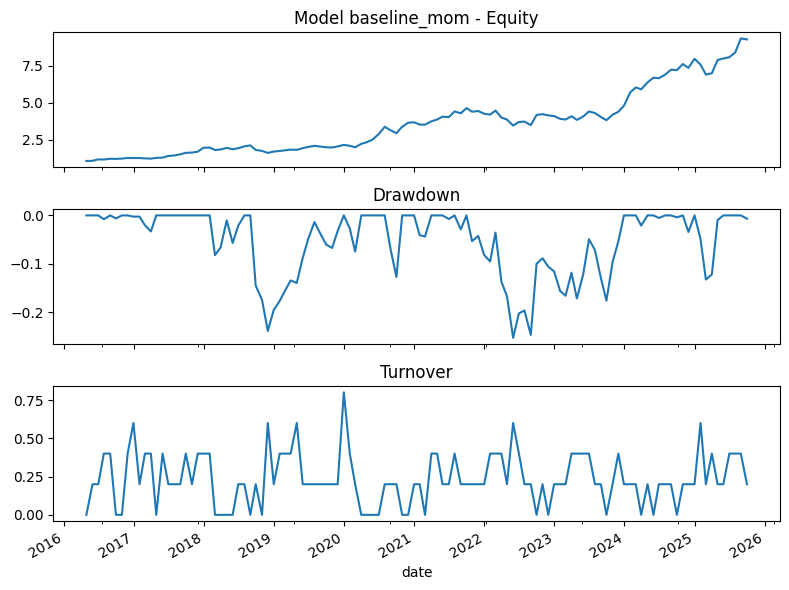

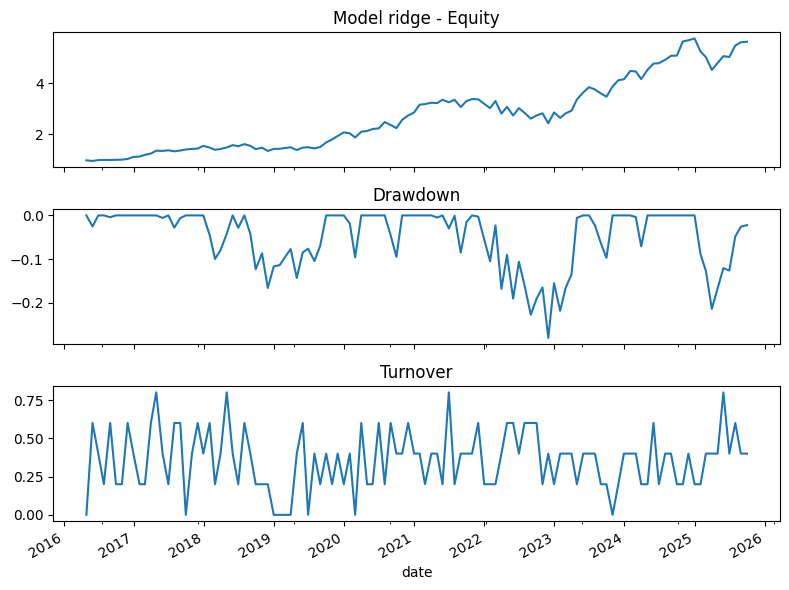

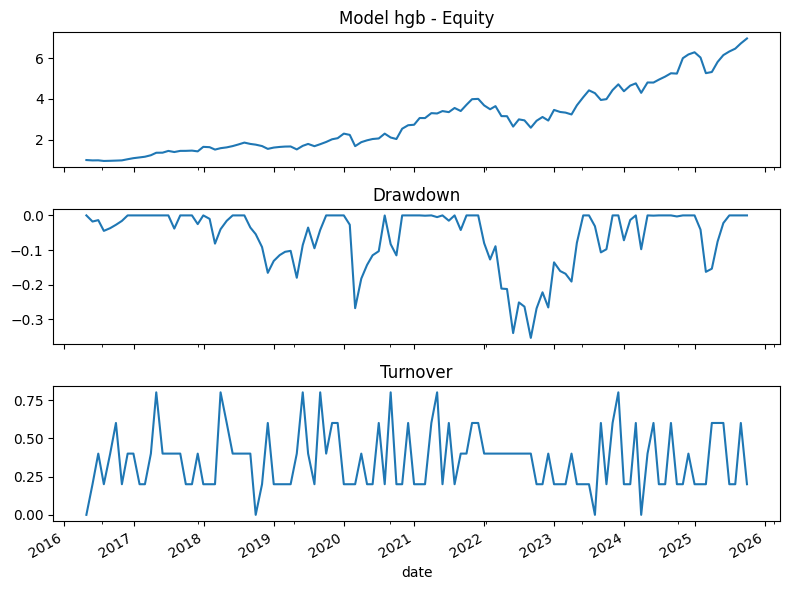

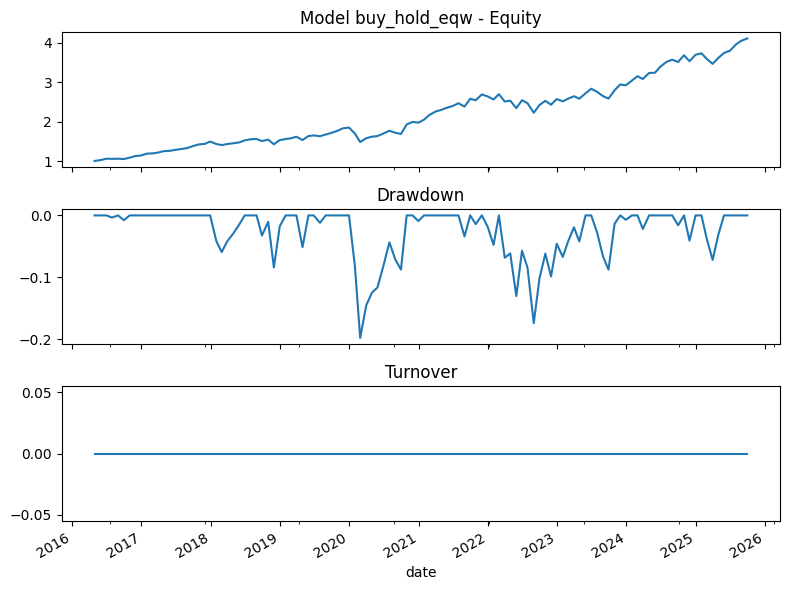

In [16]:
def plot_report(artifacts, title_prefix):
    for name, art in artifacts.items():
        fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
        art['equity'].plot(ax=axes[0], title=f'{title_prefix} {name} - Equity')
        dd = art['equity'] / art['equity'].cummax() - 1.0
        dd.plot(ax=axes[1], title='Drawdown')
        if 'turnover' in art.columns:
            art['turnover'].plot(ax=axes[2], title='Turnover')
        plt.tight_layout()


artifacts_ordered = {
    'baseline_mom': artifacts_all['baseline_mom'],
    'ridge': artifacts_all['ridge'],
    'hgb': artifacts_all['hgb'],
    'buy_hold_eqw': pd.DataFrame({
        'equity': buy_hold_equity,
        'turnover': pd.Series(0.0, index=buy_hold_equity.index),
    }),
}
plot_report(artifacts_ordered, 'Model')


### Equity curve (starting from 1000 EUR)


This block plots the equity curves for each model (scaled to the same initial capital) to compare growth over time.


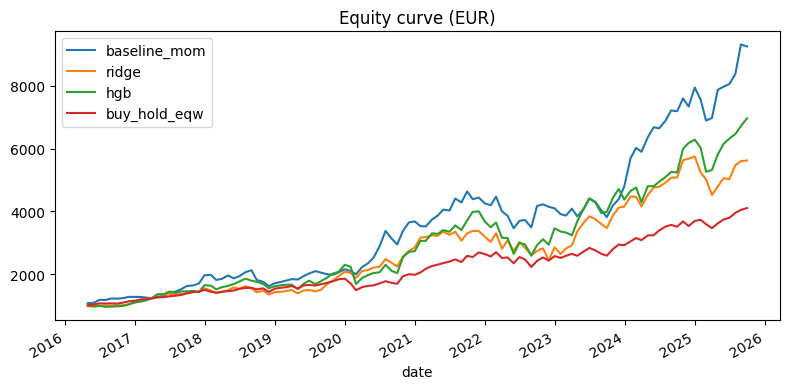

In [13]:
initial_capital = 1000.0
curves = {
    'baseline_mom': artifacts_all['baseline_mom']['equity'],
    'ridge': artifacts_all['ridge']['equity'],
    'hgb': artifacts_all['hgb']['equity'],
    'buy_hold_eqw': buy_hold_equity,
}

plt.figure(figsize=(8, 4))
for name, eq in curves.items():
    (eq * initial_capital).plot(label=name)
plt.title('Equity curve (EUR)')
plt.legend()
plt.tight_layout()


### Risk‑off exposure timeline


Shows when the overlay reduced exposure based on stress index.

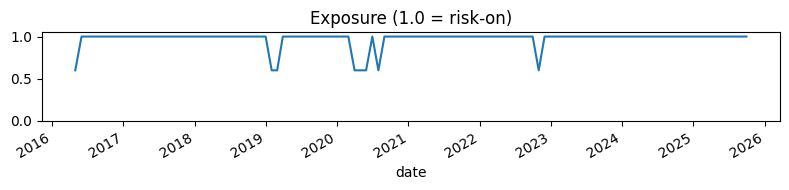

In [14]:
if bt_cfg.overlay_enabled and 'stress_index' in oos_ridge.columns:
    stress = oos_ridge.groupby('date')['stress_index'].first()
    exposure = np.where(stress > bt_cfg.stress_threshold, bt_cfg.risk_off_exposure, 1.0)
    exposure = pd.Series(exposure, index=stress.index)
    exposure.plot(figsize=(8, 2), title='Exposure (1.0 = risk‑on)')
    plt.ylim(0, 1.05)
    plt.tight_layout()
else:
    print('Overlay disabled or stress_index missing')


### IC and hit‑rate diagnostics


Compute IC and hit‑rate diagnostics on the OOS period for each model to compare predictive strength.


In [24]:
def _diagnostics(df, score_col):
    ic = mean_monthly_spearman_ic(df, 'date', score_col, io.ret_col_for_ic)
    hit = top_k_hit_rate(df, score_col, bt_cfg, ret_col=io.ret_col_for_ic)
    return ic, hit


rows = []
for name, score, df in [
    ('baseline_mom', 'score_baseline_mom', base_scores_oos),
    ('ridge', 'score_ridge', oos_ridge),
    ('hgb', 'score_hgb', oos_hgb),
]:
    ic, hit = _diagnostics(df, score)
    rows.append({'model': name, 'ic_mean': ic, 'hit_rate': hit})
display(pd.DataFrame(rows))


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/metrics.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[score_col].corr(x[ret_col], method="spearman"))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit = data.groupby(date_col).apply(_hit)
/Users/igordragone/projects/hybrid-stock-pre

,model,ic_mean,hit_rate
0,baseline_mom,0.037488,0.201754
1,ridge,0.068101,0.215789
2,hgb,0.028233,0.222807


IC (Information Coefficient) measures the cross‑sectional correlation between model scores and forward returns each month.
A higher IC means the ranking aligns better with realized returns; values around 0 are weak, positive values are better.


## Saving Results

### Save equity curves for UI comparison


In [ ]:
def save_equity(model_id, equity):
    out_dir = Path(MODELS_DIR) / model_id
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / 'equity.csv'
    equity.to_csv(path, index=True, header=True, index_label='date')


save_equity('baseline_mom', artifacts_all['baseline_mom']['equity'])
save_equity('ridge', artifacts_all['ridge']['equity'])
save_equity('hgb', artifacts_all['hgb']['equity'])
save_equity('buy_hold_eqw', buy_hold_equity)


### Save model registry entries (metrics + config)

In [ ]:

metrics_map = {row['model']: row.to_dict() for _, row in summary.iterrows()}


def save_entry(model_id, config):
    metrics = metrics_map.get(model_id, {})
    save_model_bundle(model_id=model_id, model=None, metrics=metrics, config=config)


save_entry('baseline_mom', {'type': 'baseline', 'score': 'mom12_pr'})
save_entry('ridge', {'type': 'ridge', 'features': features})
save_entry('hgb', {'type': 'hgb', 'features': features})
save_entry('buy_hold_eqw', {'type': 'benchmark', 'universe': 'equal_weight'})


### Save fold summaries (walk-forward metadata)

In [ ]:
for model_id, folds in [('ridge', folds_ridge), ('hgb', folds_hgb)]:
    out_dir = Path(MODELS_DIR) / model_id
    out_dir.mkdir(parents=True, exist_ok=True)
    folds.to_csv(out_dir / 'folds.csv', index=False)


### Fit final models and save

Train on the full dataset and persist model.pkl with the same metrics used in the backtest summary.

In [ ]:
X_full = df_model[features]
y_full = df_model[io.target_col]

final_ridge = build_ridge_pipeline(alpha=1.0)
final_ridge.fit(X_full, y_full)
save_model_bundle(model_id='ridge', model=final_ridge, metrics=metrics_map.get('ridge', {}), config={'type': 'ridge', 'features': features})

final_hgb = build_tree_model(max_depth=3, learning_rate=0.05, max_iter=300)
final_hgb.fit(X_full, y_full)
save_model_bundle(model_id='hgb', model=final_hgb, metrics=metrics_map.get('hgb', {}), config={'type': 'hgb', 'features': features})


ModelBundle(model_id='hgb', model_path=PosixPath('/Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/models/hgb/model.pkl'), metrics_path=PosixPath('/Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/models/hgb/metrics.json'), config_path=PosixPath('/Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/models/hgb/config.json'))

### Save feature importance for interpretability

In [25]:
def save_feature_importance(model_id, features, values, col_name):
    out_dir = Path(MODELS_DIR) / model_id
    out_dir.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame({'feature': features, col_name: values})
    df.to_csv(out_dir / 'feature_importance.csv', index=False)

ridge_coefs = final_ridge.named_steps['reg'].coef_
save_feature_importance('ridge', features, ridge_coefs, 'coef')

hgb_importance = final_hgb.feature_importances_
save_feature_importance('hgb', features, hgb_importance, 'importance')


NameError: name 'final_ridge' is not defined